## ECE 161C Laboratory Notebooks
---

This Juypter notebook is part of a series of computer laboratories which are designed
to teach image-processing programming. They are the practical complement of the theoretical lectures of the UCSD's course 
[**ECE 161C**](https://canvas.ucsd.edu/courses/75498) taught by Prof. Rahul Parhi.

---
# Lab 3: Orientation Lab
**Released**: Monday, 18th March, 2026  
**Due**: Wednesday, 25th March, 2026 at 11:55pm

## Install Images in Google Colab

In [ ]:
!git clone --depth 1 --filter=blob:none --sparse https://github.com/sparsity-group/161c-release.git /content/repo
%cd /content/repo
!git sparse-checkout set 3_Orientation_Lab/images
!cp -r /content/repo/3_Orientation_Lab/images /content/images
%cd /content

## Imports
Run the next cell to import some libraries.

In [1]:
# Import other standard required packages for this exercise
#%matplotlib widget 
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import ipywidgets as widgets
import time
import imageio.v3 as imageio
import scipy.ndimage as nd
import skimage

Creating dictionary for all answers

In [2]:
answers = {} # dictionary for storing answers

In [4]:
# Function to display multiple images using Matplotlib
def display_images(images, titles, fig_size = 3):
    num_images = len(images)
    fig, axes = plt.subplots(1, num_images, figsize=(fig_size * num_images, fig_size))
    
    if num_images == 1:
        axes = [axes]  # Ensure axes is iterable
    
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# 1. Orientation warm-up (3 points)

In this lab, we implement image processing algorithms and systems relying on directional analysis, i.e., on the orientation features of an image.
To obtain orientation features, we mainly use linear filtering.
In the first part of this lab, we familiarize ourselves with some tools, and discuss some *advanced* and *efficient* filtering techniques.
In particular, we implement efficient approximate Gaussian smoothing.
If anything about the basic tools is unclear, make sure to check the previous labs again.

# 1.1 Efficient Gaussian smoothing

Gaussian smoothing is a fundamental part of many image-processing algorithms.
It is often used to denoise images, improving the reliability of downstream algorithms.
Implementation of the Gaussian smoothing is provided in the next cell.
Although the separable implementation significantly improves the runtime, it is still not suitable for time-critical applications when $\sigma$ is large.
Therefore, we implement an approximate Gaussian smoothing with runtime independent of $\sigma$.

The next cell implements the separable Gaussian smoothing to compare the execution time.

In [5]:
def gaussian(sigma):
    # To capture significant influence of the Gaussian, we consider
    # pixels with up to 3*s distance. + 1 ensures an odd filter size
    # for well-defined center; see also the course notes
    n = int(2 * np.ceil(3 * sigma) + 1)
    x = np.linspace(-n // 2 + 1, n // 2, n)
    g = np.exp(-x ** 2 / (2 * sigma**2))
    return g / g.sum()


def gaussian_filter(image, sigma):
    kernel = gaussian(sigma)
    convolved = np.empty_like(image)

    for i in range(image.shape[0]):
        convolved[i] = filter1d(image[i], kernel)

    for j in range(image.shape[1]):
        convolved[:, j] = filter1d(convolved[:, j], kernel)

    return convolved
    

def filter1d(image, kernel):
    padding = kernel.shape[0] // 2
    padded = np.pad(image, padding, mode='symmetric')
    convolved = np.zeros_like(image)
    for i in range(convolved.shape[0]):
        for j in range(kernel.shape[0]):
            convolved[i] += padded[i + j] * kernel[-j - 1]
    return convolved

## 1.1.1 Generating the box filter widths (1 point)

We approximate Gaussian smoothing with successive [**box filtering**](https://en.wikipedia.org/wiki/Box_blur) passes with different box widths; 
The box kernel is a square with constant values that sum to 1; the box kernel with box width $3$ is

$$\frac{1}{9} \begin{bmatrix} 1 & 1 & 1 \\ 1 & 1 & 1 \\ 1 & 1 & 1 \end{bmatrix}\,.$$

When approximating Gaussian smoothing with successive passes of box filtering, the width of the boxes needs to be chosen to account for $\sigma$ and the number of box filter passes.
In this lab, we explore the choice proposed in [\[1\]](https://www.peterkovesi.com/papers/FastGaussianSmoothing.pdf), though other choices with benefits and drawbacks for different applications exist.
The approximation uses $m$ box filters with width $w_0, w_1, \dots, w_{m-1}$, where

$$w_i = \begin{cases}
    w_0, & \text{if } i < \gamma,\\
    w_0 + 2,              & \text{otherwise,}
\end{cases} \quad \text{where}\ \gamma = \left\lfloor \frac{12 \sigma^2 - mw_0^2 - 4mw_0 - 3 m}{-4w_0 - 4} \right\rceil.$$

There, $w_0$ is defined as

$$w_0 = \begin{cases} 
    \tilde{w}_0\,, &\mbox{if } \tilde{w}_0 \mbox{ is odd} \,, \\
    \tilde{w}_0 - 1\,, & \mbox{ otherwise,} 
\end{cases} \quad\text{and}\ \tilde{w}_0 = \left\lfloor \sqrt{\frac{12 \sigma^2}{m}+1} \right\rfloor.$$


Here, $\lfloor\,\cdot\,\rfloor$ is the floor function (see [`np.floor`](https://numpy.org/doc/stable/reference/generated/numpy.floor.html)) and $\lfloor\,\cdot\,\rceil$ is the rounding function (see [`np.around`](https://numpy.org/doc/stable/reference/generated/numpy.around.html#numpy.around)).

**For 1 point**, implement `box_widths` taking the arguments
 * `sigma`: The standard deviation of the Gaussian blur to approximate,
 * `m`: The number of box filters to use. 
 
and returning:
 * the widths $w_0$ to $w_{m-1}$ in a NumPy array according to the formulas above.

[\[1\]](https://www.peterkovesi.com/papers/FastGaussianSmoothing.pdf): "Fast Almost-Gaussian Filtering," Peter Kovesi, _2010 IEEE International Conference on Digital Image Computing: Techniques and Applications_, Sydney, NSW, Australia

In [ ]:
def box_widths(sigma, m):
    widths = np.empty(m, dtype=np.uint8)
    
    # YOUR CODE HERE

    return widths

The next cell performs some sanity checks on `box_widths`. If there is no warnings, your implementation is good.

In [ ]:
refs = {
    (3, 7): np.array([3, 3, 3, 3, 5, 5, 5]),
    (5.4, 9): np.array([5, 5, 5, 7, 7, 7, 7, 7, 7]),
}
ours = {args: box_widths(*args) for args in refs.keys()}

if len(ours[(3, 7)]) != 7:
    print('Warning: The length of the output list should be equal to m.')

if np.any(ours[(3, 7)] % 2 == 0):
    print('Warning: Ensure that the box widths are always odd.')

for args in refs.keys():
    our = ours[args]
    ref = refs[args]
    if not np.allclose(our, ref):
        print(f'Warning: The output for {args} should be {ref}, got {our}.')
    

We compare the box filter approximation to the exactly discretized Gaussian filter and calculate the error between the impulse responses depending on the number of box filters used.
You can change $\sigma$ with the slider below the figure, and you change the maximum number of box passes in the code (now set to $5$).
Observe the effect this has on the MSE.

In [ ]:
def mse_db(a, b):
    length = max(len(a), len(b))
    a_pad = np.pad(a, (length - len(a)) // 2)
    b_pad = np.pad(b, (length - len(b)) // 2)
    return 10*np.log10(np.mean((a_pad - b_pad) ** 2))


sigma_slider = widgets.FloatSlider(value=0.2, min=0.2, max=8, step=0.2, description='\u03C3', continuous_update=False) 
box_passes = 5
ns = np.arange(1, box_passes + 1)

plt.close('all')
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

def plot_approximation(change):
    sigma = change.new
    errors = []
    axs[0].clear()
    axs[1].clear()
    n = int(2 * np.ceil(3 * sigma) + 1)
    x_g = np.linspace(-n // 2 + 1, n // 2, n)
    gauss_exact = gaussian(sigma)
    axs[0].plot(x_g, gauss_exact, 'k')
    # Iterate through box filters
    for p, n in enumerate(ns):
        boxes = box_widths(sigma, n)
        conv = np.ones(boxes[0]) / boxes[0]
        for i in range(1, len(boxes)):
            box = np.ones(boxes[i]) / boxes[i]
            conv = np.convolve(conv, box)
        x_b = np.linspace(-conv.shape[0]//2+1, conv.shape[0]//2, conv.shape[0])
        errors.append(mse_db(conv, gauss_exact))
        axs[0].plot(x_b, conv, alpha=0.5)
    # Format plot
    axs[0].legend(['Exact Gaussian'] + [f'{n} box passes' for n in ns])
    axs[0].set_xlabel('x')
    axs[0].set_ylabel('h[x]')
    axs[0].set_title(f'Gaussian $\\sigma$={sigma:.2f} vs Box filter approximations')
    axs[0].grid()
    axs[1].plot(ns, errors)
    axs[1].set_xlabel('Number of box passes')
    axs[1].set_ylabel('MSE [dB]')
    axs[1].set_title(f'MSE, Gaussian $\\sigma$={sigma:.2f} vs Box filter approximations')
    axs[1].grid()
    fig.tight_layout()

# Didplay widget and link to callback
display(sigma_slider)
sigma_slider.observe(plot_approximation, 'value')
sigma_slider.value = 3

We observe that method does not work well for small $\sigma$, as the box widths are all 1.
However, when $\sigma > 0.6$ the results are acceptable.
We now plot the MSE between the approximation and the exactly discretized Gaussian depending on $\sigma$, with $\sigma$ ranging from $0.6$ to $10$. 
We can change the number of box filtering passes using the slider below the figure.
Observe the effect this has on the MSE.

In [ ]:
# Initialize slider to define the number of box filters to use
box_slider = widgets.IntSlider(value=1, min=1, max=12, step=1, description='Number of box passes', continuous_update=False, 
                               style={'description_width':'initial'}, layout={'width':'400px'}) 

# Declare array with sigma values to evaluate
sigmas = np.linspace(0.5, 10, 1000)

# Initialize Matplotlib figure
plt.close("all")
fig = plt.figure(figsize = (10,6))
ax = plt.gca()

def plot_mse(change):
    n = change.new
    ax.clear()
    errors = []
    for sigma in sigmas:
        gauss_exact = gaussian(sigma)
        boxes = box_widths(sigma, n)
        conv = np.ones(boxes[0]) / boxes[0]
        for i in range(1, len(boxes)):
            box = np.ones(boxes[i]) / boxes[i]
            conv = np.convolve(conv, box)
        errors.append(mse_db(conv, gauss_exact))
    ax.plot(sigmas, errors);
    ax.set_xlabel('$\\sigma$'); ax.set_ylabel('MSE [dB]')
    ax.set_title(f'MSE, {n} box filter approximation vs Gaussian impulse response')
    ax.grid()
    
display(box_slider)
box_slider.observe(plot_mse, 'value')
box_slider.value = 6

## 1.1.2 Implementation of a separable accumulation box filter (2 points)

Given the previous analysis, we stick to $m=4$ box filter passes, offering a good compromise between numerical accuracy and execution time. 
We now implement the box filtering efficiently via a **separable accumulator**, making execution time independent of the width of the filter.
In detail, as the box filter is constant, computing the next unknown output amounts to adding the new pixel now covered by the filter and subtracting the pixel no longer covered by the filter.
Thus, the computation time is independent of the filter width, as we only need to perform $2$ operations per pixel (besides the very first pixel in every row/column).
The accumulator needs to be filled only for the first output pixel.

A visual representation of a horizontal accumulation box filter of **width 5** using mirroring boundary conditions applied to the first row is given below.

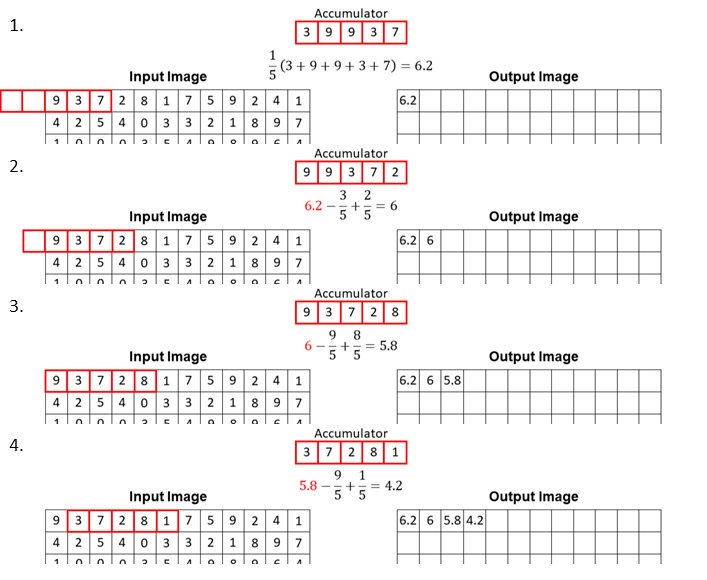



In the next cell, we have implemented `box_gauss_approximation`, which approximates the Gaussian filter through successive passes of box filters with different widths.
Since the box filter is separable, we implement the two-dimensional box filter as two passes of a one-dimensional box filter.
**For 2 points**, implement `box_filter1d` using the accumulator strategy.

In [8]:
def box_gauss_approximation(img, sigma, m=4):
    output = img.copy()
    widths = box_widths(sigma, m)
    for width in widths:
        output = box_filter2d(output, width=width)
    return output


def box_filter2d(image, width):
    convolved = np.empty_like(image)

    for i in range(image.shape[0]):
        convolved[i] = box_filter1d(image[i], width)

    for j in range(image.shape[1]):
        convolved[:, j] = box_filter1d(convolved[:, j], width)

    return convolved


def box_filter1d(image, width):
    padding = int(width // 2)
    padded = np.pad(image, padding, mode='symmetric')
    convolved = np.zeros_like(image)
    # YOUR CODE HERE
    
    return convolved / width

The next cell has a sanity check on a small example. If there is no warnings, your implementation is good.

In [9]:
test_img = np.zeros((5, 5))
test_img[0, 0] = 1
test_img[2, 2] = 1
test_img[4, 4] = 1

comp = np.array([
    [4/9, 2/9, 0, 0, 0],
    [2/9, 2/9, 1/9, 1/9, 0],
    [0, 1/9, 1/9, 1/9, 0],
    [0, 1/9, 1/9, 2/9, 2/9],
    [0, 0, 0, 2/9, 4/9]
])

convolved = box_filter2d(test_img, 3)

if not np.allclose(convolved, comp): print('Your function does not pass the sanity check')


Your function does not pass the sanity check


# Runtime comparison

Finally, we compare the box filter approximation to the separable Gaussian filter.
First, we compare the runtime of both methods depending on the standard deviation of the Gaussian.
You can experiment with the values, but beware that large sigmas lead to long runtime!
The cell below runs both smoothing methods for all the $\sigma$ values defined in the cell above on the image `dendrochronology`, which has a size of $512 \times 512$ pixels.

In [ ]:
image = imageio.imread('images/dendrochronolgy.tif') / 255.


sigmas = [0.1, 1, 2, 3, 4, 5, 8]
errors, times_approx, times_exact = [np.empty((len(sigmas), )) for _ in range(3)]
print('Running for s =', end=' ')
for i, sigma in enumerate(sigmas):
    print(f'{sigma:.1f},', end=' ')
    
    start = time.time()
    approximated = box_gauss_approximation(image, sigma)
    times_approx[i] = time.time() - start
    
    start = time.time()
    exact = gaussian_filter(image, sigma)
    times_exact[i] = time.time() - start

print('\nFinished running.')

plt.close('all') 
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(sigmas, times_exact, marker='o')
ax[0].plot(sigmas, times_approx, marker='s')
ax[0].legend(['Separable Gaussian', 'Accumulation box filters'])
ax[0].set_xlabel('$\\sigma$')
ax[0].set_ylabel('Runtime [s]')
ax[0].grid()
ax[0].set_title('Runtime comparison')
ax[1].plot(sigmas, times_exact / times_approx, marker='^')
ax[1].set_xlabel('$\\sigma$');
ax[1].grid()
ax[1].set_title('Speedup')
plt.show()

We see that the runtime of the accumulation box filters is independent of $\sigma$, whereas the runtime of the separable Gaussian increases linearly with $\sigma$.
For a non-separable Gaussian filter we would probably still be waiting for the results as the runtime is proportional to $\sigma^2$, demonstrating the benefit of separable filters and the accumulation strategy.

Finally, we compare the accuracy of our method to the Gaussian filter provided by SciPy.

In [ ]:
sigmas = [0.5, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 22, 26, 30]

exact = np.empty((len(sigmas), *image.shape))
approx = np.empty((len(sigmas), *image.shape))
errors = np.empty((len(sigmas), ))
print('Running for \u03C3 =', end=' ')
for i, sigma in enumerate(sigmas):
    print(f"{sigma:.1f},", end=' ')
    approx[i] = box_gauss_approximation(image, sigma)
    exact[i] = nd.gaussian_filter(image, sigma, radius=int(np.ceil(3 * sigma)))
    errors[i] = mse_db(exact[i], approx[i])


print('\nFinished running for all standard deviations.')

# Display result
plt.close('all')
plt.figure('Average pixel error')
plt.plot(sigmas, errors)
plt.xlabel('$\\sigma$')
plt.ylabel('Avg pixel error (%)')
plt.title('Average error per pixel')
plt.grid()
plt.show()

In accordance with the previous analysis, the approximation works well for large standard deviations, getting an MSE below $-50$dB, which is acceptable for most applications.

Finally, run the cell below to visually compare the smoothed images.

In [ ]:
# Change the sigma index (0- 18) to see the result for different sigmas 
sigma_idx = 11

In [ ]:
# Give information
print(f'Average pixel error for σ={sigmas[sigma_idx]}: {errors[sigma_idx]:.4f}%')

display_images([image, exact[sigma_idx], approx[sigma_idx]], ['Original Image', rf'Gaussian $\sigma={sigmas[sigma_idx]}$', rf'Box filter $\sigma={sigmas[sigma_idx]}$'], 3)

# 2. Orientation laboratory (13 points)

In this lab, we implement the computation of the structure tensor, which can be used to perform directional image analysis.
The block diagram of the complete system is shown in the following flowchart, where $f(x,y)$ is the grayscale input image.

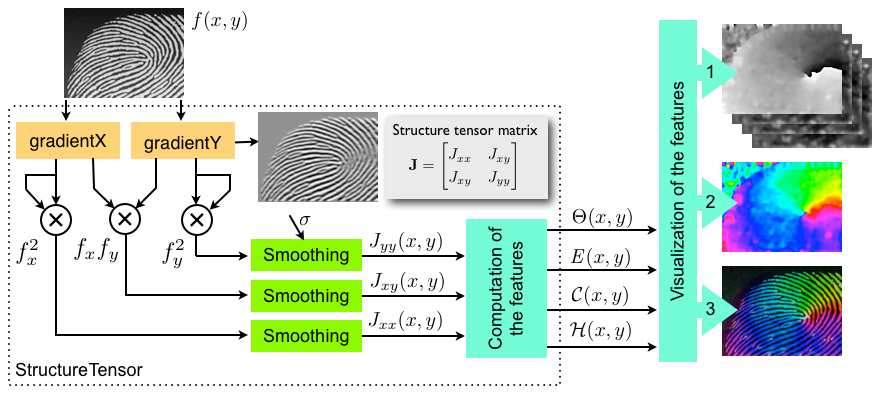

Successively, we implement the functions
* `structure_tensor` to generate the structure tensor matrix,
* `orientation_features`, which implements the whole chain of calculations to generate the features needed for directional analysis, and
* `colorize_features` to display the calculated features as a color image.

Then, we use them in two applications relying on directional image analysis,
* a method to select specific orientations, and
* a keypoint detector (Harris corner detector). 

Finally, we discuss an alternative implementation of `structure_tensor`, improving over the previous version.

# 2.1 Structure tensor (2 points)

To calculate the elements $J_{xx}$, $J_{xy}$ and $J_{yy}$ of the structure tensor, we need a gradient filter and a Gaussian filter.
For the gradient filter, we use [`scipy.ndimage.sobel`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.sobel.html) and for the Gaussian filter, we use [`scipy.ndimage.gaussian_filter`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_filter.html).

**For 2 points**, implement `structure_tensor` in the cell below. It may be useful to revisit the [figure](#Orientation-laboratory-(13-points)) above.

In [ ]:
def structure_tensor(img, sigma):
    Jxx, Jxy, Jyy = [np.empty_like(img) for _ in range(3)]

    # YOUR CODE HERE
    
    return Jxx, Jxy, Jyy

We perform a quick sanity check on a $11 \times 11$ **impulse image** using `sigma=1`. 
You can modify the input image and the sigma value in the cell below to observe the different results.

In [ ]:
size = 11
test_img = np.zeros((size, size))
test_img[size//2, size//2] = 1

Jxx, Jxy, Jyy = structure_tensor(test_img, sigma=1)

display_images([test_img, Jxx, Jyy, Jxy], ['test_img', 'Jxx', 'Jyy', 'Jxy'], 3)

Specifically, we check if $J_{xx}$ and $J_{yy}$ are non-negative and $\pi / 2$ rotations of each other, which should be the case for the impulse image.
Then, we check that $J_{xy}$ contains both negative and non-negative numbers, and that all elements that are either in the fifth row or the fifth column of $J_{xy}$ are zero. 

Because the structure tensor is a crucial part of this lab, we will also perform more sophisticated sanity checks comparing your results to our pre-computed correct results.

In [ ]:
corner, dendrochronology, fingerprint, harris_corner, wave_ramp = [
    imageio.imread(f'images/{name}.tif') / 255.
    for name in ['corner', 'dendrochronolgy', 'fingerprint', 'harris-corner', 'wave-ramp']
]

In [ ]:
# you can change the image to any of the ones we imported: corner, dendrochronology, fingerprint, harris_corner, or wave_ramp
image = wave_ramp

In [ ]:
Jxx, Jxy, Jyy = structure_tensor(image, sigma=1)
plt.close('all')
display_images([image, Jxx, Jxy, Jyy], ['image', 'Jxx', 'Jyy', 'Jxy'], 3)

In [ ]:
# Basic sanity checks
test_img = np.zeros((11, 11))
test_img[5, 5] = 1
Jxx, Jxy, Jyy = structure_tensor(test_img, sigma=1)

if not (np.all(Jxx >= 0) and np.all(Jyy >= 0)): 
    print('WARNING!\nJxx and Jyy should be non-negative')
if not np.allclose(np.rot90(Jxx), Jyy):
    print('WARNING!\nJxx should be a rotation of Jyy')
if not np.any(Jxy > 0) and np.any(Jxy < 0):
    print('WARNING!\nJxy should be positive and negative')
if not np.all(abs(Jxy[5, :]) < 1e-5) and np.all(abs(Jxy[:, 5]) < 1e-5):
    print('WARNING!\nFifth row/col should be zero')

# Comparison to pre-computed correct results
Jxx_corr = np.array([
    [0.004, 0.018, 0.033, 0.035, 0.033, 0.018, 0.004],
    [0.025, 0.114, 0.209, 0.224, 0.209, 0.114, 0.025],
    [0.077, 0.35,  0.644, 0.688, 0.644, 0.35,  0.077],
    [0.113, 0.512, 0.942, 1.006, 0.942, 0.512, 0.113],
    [0.077, 0.35,  0.644, 0.688, 0.644, 0.35,  0.077],
    [0.025, 0.114, 0.209, 0.224, 0.209, 0.114, 0.025],
    [0.004, 0.018, 0.033, 0.035, 0.033, 0.018, 0.004]
])
Jyy_corr = Jxx_corr.T
Jxy_corr = np.array([
    [ 0.003,  0.013,  0.019,  0.   , -0.019, -0.013, -0.003],
    [ 0.013,  0.056,  0.082,  0.   , -0.082, -0.056, -0.013],
    [ 0.019,  0.082,  0.119,  0.   , -0.119, -0.082, -0.019],
    [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
    [-0.019, -0.082, -0.119,  0.   ,  0.119,  0.082,  0.019],
    [-0.013, -0.056, -0.082,  0.   ,  0.082,  0.056,  0.013],
    [-0.003, -0.013, -0.019,  0.   ,  0.019,  0.013,  0.003]
])

for yours, reference in zip([Jxx[2:9, 2:9], Jyy[2:9, 2:9], Jxy[2:9, 2:9]], [Jxx_corr, Jyy_corr, Jxy_corr]):
    if not np.allclose(Jxx[2:9, 2:9], Jxx_corr, atol=1e-3): print('Your function does not pass the sanity check')


Now we can apply `structure_tensor` to any of the images (`corner`, `dendrochronology`, `fingerprint`, `harris_corner`, or `wave_ramp`) to inspect the elements of the structure tensor.
In the cell below, you can change the argument to `structure_tensor` to any image and change `sigma` to observe the effect on the result.

# 2.2 Orientation features

With the structure tensor, we can compute features to help us understand and visualize the orientation of structures in an image.
An easy way to think about the structure tensor is that, for each pixel location `[m,n]`, we can calculate a matrix $\mathbf{J}$ made out of the values of $J_{xx}$, $J_{yy}$, and $J_{xy}$ at that pixel, 

$$
    \mathbf{J}[m,n] = \left[ \begin{array}{cc} J_{xx}[m,n] & J_{xy}[m,n] \\ J_{xy}[m,n] & J_{yy}[m,n]\end{array} \right]\,.
$$

## 2.2.1 Feature calculation (4 points)

The following table below shows four features we will compute from the structure tensor (the indices are dropped for simplicity).
There, $\det$ is the determinant and $\operatorname{tr}$ is the trace.

| Feature | Relation to the structure tensor matrix $\mathbf{J}$ |
| :-: | :-: |
| Orientation | $\Theta = \frac{1}{2}\arctan\left(\frac{2J_{xy}}{J_{yy}-J_{xx}}\right)$ |
| Gradient Energy | $E = J_{yy}+J_{xx}$ |
| Coherence | $C = \frac{\sqrt{(J_{yy}-J_{xx})^2+4J_{xy}^2}}{E}$ if $E > 0.01$ else 0 |
| Harris Index | $H = \det(\mathbf{J}) - \kappa \operatorname{tr}(\mathbf{J})^2\mbox{, with }\kappa = 0.05$ |

In the cell below, complete `orientation_features`, implementing the processing chain described in the flowchart at the start of this notebook.
Use `structure_tensor` from the previous section and implement the features (**1 point each**) specified in the table.
Use `np.arctan2` for $\arctan$, as it calculates the correct quadrant.

In [ ]:
def orientation_features(img, sigma, structure_tensor=structure_tensor):
    orientation, energy, coherence, harris = [np.zeros_like(img) for _ in range(4)]

    # YOUR CODE HERE
    
    return orientation, energy, coherence, harris

In [ ]:
# Change the input image and sigma, to see the result on different images: corner, dendrochronology, fingerprint, harris_corner, or wave_ramp
input_img = wave_ramp
sigma = 2

In [ ]:
images = [input_img] + list(orientation_features(input_img, sigma=sigma))
# Display the output features
titles = ['Input image', 'Orientation', 'Energy', 'coherence', 'Harris Index']
plt.close('all')
display_images(images, titles, 2)

As a sanity check, you can run the next four cells to check that each of the output features is in the correct range when applying the function to the `wave_ramp` image using `sigma = 2`.

In [ ]:
# Sanity checks
orientation, energy, coherence, harris = orientation_features(wave_ramp, sigma=2)
if not (abs(orientation.min() + np.pi / 2) < 0.01 and abs(orientation.max() - np.pi / 2) < 0.01):
    print('WARNING!\nThe orientation should be in [-pi/2, pi/2].')


In [ ]:
if not (abs(energy.min() - 0.00023718704) < 0.01 and abs(energy.max() - 0.00044379648) < 0.01):
    print('WARNING!\nThe energy should be in [0.00023718704, 0.00044379648].')
    

In [ ]:
if not (abs(coherence.min()) >= 0.0 and abs(coherence.max()) <= 1.0):
    print('WARNING\nThe coherence should be in the range [0, 1].')
    

In [ ]:
if not (abs(harris.min() + -9.831781e-09) < 0.01 and abs(harris.max() - 2.6322816e-08) < 0.01):
    print('WARNING!\nThe Harris index should be in [9.831781e-09, 2.6322816e-08].')
    

## 2.2.2 Feature visualization (2 points)

Until now, we used grayscale images to visualize the orientation features, allowing only a single feature to be displayed at once.
However, we often want to visualize several features in the same image, making the visual analysis more intuitive.
We do this by leveraging the **hue, saturation, value (HSV)** color representation depicted below.
We assign the orientation (which is $2\pi$ periodic) to the hue (which is also periodic), the coherence (a value between $0$ and $1$) to the saturation, and the original image to the value, which allows us to see the objects in the image.


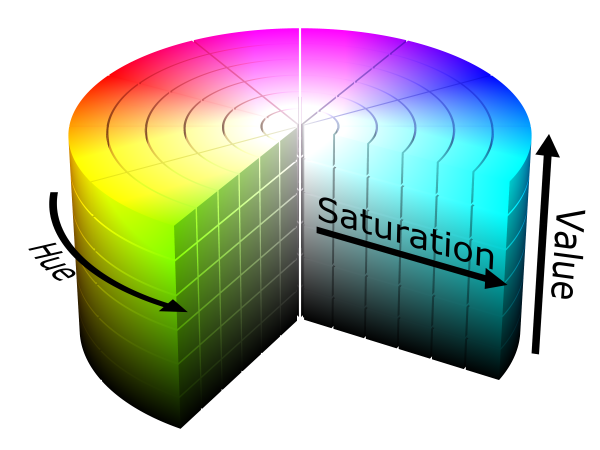

**For 2 points**, implement `colorize_features`, taking *orientation*, *coherence*, *input image*, and a *mode* (see table below) as arguments. The function should create an HSV image `hsv_image` from the orientation features, which is converted to RGB to display it.

The function will have two modes:
In both modes, the orientation $o \in [-\pi/2, \pi/2]$ is mapped to $[0, 1]$ via $o \mapsto (o + \pi/2) / \pi$, which is put into the hue channel.
In mode $0$, the saturation and value channels are left constant at `1`.
In mode $1$, the coherence is put into the saturation channel, and the input image is put into the value channel.
The coherence and the input image can be directly used without any transformation.
See the table below for the specifications of the two modes.  

| Mode | H channel | S channel | V channel |
| :-: | :-: | :-: | :-: |
| 0: Orientation only | orientation | 1 | 1 |
| 1: Features on image | orientation | coherence | input image |

In [ ]:
def colorize_features(orientation, coherence, img, mode=1):
    # Fill hsv_img[:, :, 0] to set the hue, hsv_img[:, :, 1] to set the saturation, and hsv_img[:, :, 2] to set the value
    hsv = np.zeros((*img.shape, 3))

    # YOUR CODE HERE

    # Convert HSV to RGB
    return matplotlib.colors.hsv_to_rgb(hsv)

Now run the next two cells for a quick test on your function. As usual, remember that these tests are not definitive and that they do not guarantee the full points.

In [ ]:
orientation = np.array([[-np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2]])
coherence   = np.array([[0, 65, 130, 195, 255]]) / 255.
img = np.array([[255, 195, 130, 65, 0]]) / 255.
reference = np.array([[[1, 0, 0], [0.5, 1, 0], [0, 1, 1],[0.5,   0, 1], [1,   0,   0]]])

colorized_img = colorize_features(orientation, coherence, img, mode=0)
if not np.allclose(colorized_img, reference):
    print('WARNING!\nYour colorization function is not yet correct for mode 0. Check the comparison below:')
    display_images([colorized_img, reference],['Your output', 'Expected output'])

In [ ]:
orientation = np.array([[-np.pi / 2, -np.pi / 4, 0, np.pi / 4, np.pi / 2]])
coherence   = np.array([[0, 65, 130, 195, 255]]) / 255.
img = np.array([[255, 195, 130, 65, 0]]) / 255.
reference = np.array([[[1.,         1.,         1.],
  [0.66724337, 0.76470588, 0.56978085],
  [0.24990388, 0.50980392, 0.50980392],
  [0.15743945, 0.05997693, 0.25490196],
  [0.,         0.,         0.,        ]]])

colorized_img = colorize_features(orientation, coherence, img, mode=1)
if not np.allclose(colorized_img, reference):
    print('WARNING!\nYour colorization function is not yet correct for mode 1. Check the comparison below:')
    display_images([colorized_img, reference],['Your output', 'Expected output'])

Below we visualize the effect of `colorize_features` function on different images. Change mode for Orientation and Features on image.

In [ ]:
# Choose a fixed sigma and mode:
sigma_value = 5
mode = 0  # 0 => Orientation only, 1 => Features on image

In [ ]:
image = wave_ramp
orientation, energy, coherence, harris = orientation_features(image, sigma=sigma_value)
wave_ramp_rgb = colorize_features(orientation, coherence, image, mode=mode)
image = dendrochronology
orientation, energy, coherence, harris = orientation_features(image, sigma=sigma_value)
dendrochronology_rgb = colorize_features(orientation, coherence, image, mode=mode)
image = fingerprint
orientation, energy, coherence, harris = orientation_features(image, sigma=sigma_value)
fingerprint_rgb = colorize_features(orientation, coherence, image, mode=mode)
# display results
display_images([wave_ramp_rgb, dendrochronology_rgb, fingerprint_rgb], ['wave_ramp_rgb', 'dendrochronology_rgb', 'fingerprint_rgb'],4)

# 3. Application

We implement applications relying on functions implemented in the previous sections, outlining their merit in real-life applications.

## 3.1 Orientation selection (2 points)

We develop a function that only selects areas of the image with a specific orientation.
In particular, the algorithm should preserve pixels where
 - $E > T E_{max}$, where $E_{max}$ is the maximum energy in the image and $T\in[0, 1]$ is a relative threshold,
 - $C > 0.5$,
 - $\theta_{min} \leq \theta(x, y) \leq \theta_{max}$.

**For 2 points**, implement the function `select_direction` taking the arguments
* `img`: The input image
* `sigma`: $\sigma$ to be used in `orientation_features`
* `T`: The relative energy threshold
* `theta_min`: The minimum angle $\theta_{min}$
* `theta_max`: The maximum angle $\theta_{max}$

and returning

* `output`: Output image keeping the pixels with the given features, with all other pixels set to the minimum value of the image (not necessarily 0).

Use the function `orientation_features` you implemented in [Part 2.A.](#2.A.-Feature-calculation-(4-points)) to get the features needed.

**Note:** We account for the periodicity of $\theta$ as follows:
If $\theta_{\mathrm{min}} \leq \theta_{\mathrm{max}}$ then return the values inside the range $[\theta_{\mathrm{min}}, \theta_{\mathrm{max}}]$, otherwise return the values that are outside this range, i.e., $[-\pi/2,\pi/2] \setminus (\theta_{\mathrm{max}}, \theta_{\mathrm{min}})$ (see [relative complement](https://en.wikipedia.org/wiki/Complement_(set_theory)#Relative_complement)).
As an example, if $\theta_{\mathrm{min}} = \frac{\pi}{3}$ and $\theta_{\mathrm{max}} = -\frac{\pi}{3}$, the function should keep all orientation in the ranges $[\frac{\pi}{3}, \frac{\pi}{2}]$ and $[-\frac{\pi}{2}, -\frac{\pi}{3}]$ but discard all orientations in the range $(-\frac{\pi}{3}, \frac{\pi}{3})$.

In [ ]:
def select_direction(img, sigma, T, theta_min, theta_max):
    assert -np.pi/2 <= theta_min <= np.pi/2, 'theta_min should be in [-pi/2, pi/2]'
    assert -np.pi/2 <= theta_max <= np.pi/2, 'theta_max should be in [-pi/2, pi/2]'
    
    output = img.copy()
    
    # YOUR CODE HERE
    
    return output

The next cell will evaluate your function on a test image that consists of 4 lines at the angles $0$, $\frac{\pi}{4}$, $-\frac{\pi}{4}$ and $\frac{\pi}{2}$. The function will be called on this test image with the ranges $[-\frac{\pi}{6}, \frac{\pi}{6}]$, $[\frac{\pi}{6}, \frac{\pi}{3}]$, $[-\frac{\pi}{3}, -\frac{\pi}{6}]$, and $[\frac{\pi}{3}, -\frac{\pi}{3}]$, which should each extract only one of the lines. Run the cell below to apply this sanity check.

In [ ]:
# Create test image consisting of 4 lines at 0, pi/2, pi/4 and -pi/4
n = 49
r = n // 2

line0 = np.zeros((n, n))
line0[r, :r-6] = 1
line0[r, r+7:] = 1
line0 = np.pad(line0, 1)

line90 = np.rot90(line0)

line45 = np.zeros((n, n))
line45[range(n-1, r+6, -1), range(r-6)] = 1
line45[range(r-7, -1, -1), range(r+7, n)] = 1
line45 = np.pad(line45, 1)

lineM45 = np.rot90(line45)

# Combine lines into a single test image
test_img = line0 + line90 + line45 + lineM45

# Display the test_img
display_images([test_img], ["Test Image"], fig_size=4)

# Prepare lines and angle ranges for checking
lines = [line0, line45, lineM45, line90]
ranges = [
    [-np.pi/6, np.pi/6],      # near 0° (horizontal)
    [np.pi/6, np.pi/3],       # diagonal ascending
    [-np.pi/3, -np.pi/6],     # diagonal descending
    [np.pi/3, -np.pi/3]       # near 90° (vertical) - note wrap-around
]
names = ['horizontal', 'diagonal ascending', 'diagonal descending', 'vertical']

check = True

# Test each orientation range
for i, ran in enumerate(ranges):
    test_dir = select_direction(test_img, sigma=2, T=0.1, theta_min=ran[0], theta_max=ran[1])
    
    # Compare with the expected single-line image (lines[i]).
    if not np.allclose(test_dir, lines[i]):
        check = False
        print(f"WARNING!\nOnly the {names[i]} line should be visible at "
              f"theta_min={ran[0]:.3f}, theta_max={ran[1]:.3f}!\n")
        
        # Show side-by-side images to compare
        display_images(
            [test_dir, lines[i]],
            [
                f'Your output for min={ran[0]:.3f}, max={ran[1]:.3f}',
                'Expected output'
            ],
            fig_size=4
        )

if check:
    print('Well done, your function passed the sanity check!')

In the next cell, we apply our function to real images and play around with the different parameters. For some images, $T$ needs to be very small to extract any orientation.

In [ ]:
images = [wave_ramp, dendrochronology, fingerprint]
# User-specified values
image_index = 2       #  value in 0,1,2
sigma_value = 3       #  value in [1,15]
T_value = 0.05        #  value in [0,1] 
theta_min = -np.pi/4  #  value in [-np.pi/2, np.pi/2]
theta_max = np.pi/4   #  value in [-np.pi/2, np.pi/2]

In [ ]:
image = images[image_index]
# Apply orientation selection
selected = select_direction(
    img=image, 
    sigma=sigma_value, 
    T=T_value, 
    theta_min=theta_min, 
    theta_max=theta_max
)

# Display side by side
display_images(
    [image, selected],
    [f"Original image (index={image_index})", f"Selected Orientation\nσ={sigma_value}, T={T_value}, "
     f"θ_min={theta_min:.2f}, θ_max={theta_max:.2f}"],
    fig_size=4
)

## 3.2 Harris corner detector (2 points)

The Harris index can be interpreted as the probability of having a corner.
Thus, we can implement a basic corner detector by extracting the local maxima of the Harris index image.

**For 1 point**, complete `detect_corners` taking as arguments
 * `img`: The input image
 * `region_size`: At most one peak is supposed to be detected in a (region_size x region_size) region
 * `threshold`: a relative threshold in the range $[0, 1]$, where only local maxima that are above $T$ times the image maximum are kept. 

and returning
 * `output`: Coordinated of the local maxima.

Get the Harris index using `orientation_features` with `sigma=1`.
To extract the local maxima, use [`skimage.feature.peak_local_max`](https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.peak_local_max).
`min_distance` in `peak_local_max` is related to `region_size` by `region_size = 2 * min_distance + 1`.

In [ ]:
def detect_corners(img, region_size, threshold):
    # This is a dummy initialization; the output should be an array of shape (detected_points, 2)
    output = img.copy()
    # YOUR CODE HERE
    
    return output


def visualize_corners(img, corners):
    peak_mask = np.zeros_like(img)
    peak_mask[tuple(corners.T)] = True
    corners = skimage.morphology.dilation(peak_mask)
    output = np.tile(img[..., None], (1, 1, 3))
    output[corners > 0] = [1, 0, 0]
    return output

Run the next cell to test your `detect_corners` function on a test image that contains 12 corners. Your function should be able to detect them all correctly.

In [ ]:
# Create test image
n = 51
r = n // 2
test_img = np.zeros((n, n))
test_img[r - 15:r + 16,r - 5:r + 6] = 1
test_img[r - 5:r + 6,r - 15:r + 16] = 1

detected_corners = detect_corners(test_img, 3, 0.5)

plt.close('all')
display_images([visualize_corners(test_img, detected_corners)],['detected corners'])
# Check that the number of detected corners is 12
if len(detected_corners) != 12:
    print(f'Warning: Detected {len(detected_corners)} corners instead of 12.')
else:
    print("Correctly detected 12 corners in the image. Verify the correct location by looking at the picture.")


In the cells below, experiment with `region_size` and `threshold`.
We use this information to answer the upcoming MCQ.

In [ ]:
# Change the input image, T and T values, to see the result on different images: corner, harris_corner
image = corner
T_value = 0.05        #  value in [0,1]
L_value = 10           #  value in [1,31] 

In [ ]:
# Detect corners
corners = detect_corners(image, region_size=L_value, threshold=T_value)
print(f"number of corner: {len(corners)}")

# Visualize the corners (overlay red points on the original image)
image_with_corners = visualize_corners(image, corners)

# Display side-by-side for comparison
display_images(
    [image, image_with_corners],
    titles=["Original Image", f"Corners (T={T_value}, L={L_value})"],
    fig_size=5
)

### Multiple Choice Question

For **0.5 points** each, solve the following:

* Q1: In general, a higher $L$ leads to
    1. more corners, because a higher area is covered,
    2. less corners, because values need to be a local maximum in a larger area,
    3. less corners, because fewer areas of the image are observed, or
    4. more corners, because more areas of the image are observed.


* Q2: In general, selecting a higher $T$ means that a corner has to be ... to be detected.
    1. sharper, so that it's more defined,
    2. rounder, so that it's less defined, or
    3. more diffuse, so that it covers more area.
 
In the next cell, modify the answers variable to reflect your answers. The following two cells are for you to check that your answer is in the valid range.

In [ ]:
# Assign your answer to this variable
answers['Q1'] = None
answers['Q2'] = None
# YOUR CODE HERE

In [ ]:
# Sanity check
if not answers['Q1'] in [1, 2, 3, 4]:
    print('WARNING!\nChoose one of 1, 2, 3 or 4.')

In [ ]:
# Sanity check
if not answers['Q2'] in [1, 2, 3]:
    print('WARNING!\nChoose one of 1, 2 or 3.')

## 3.3 *Advanced:* Isotropic filtering in the Fourier space (1 point)

In the first exercise, we used the Sobel filter to compute the gradient for the structure tensor.
We illustrate the *anisotropy* of the Sobel filter using an image that contains the same number of pixels for every possible orientation.

In [ ]:
def create_test_img(ny, nx):
    # Minimum and maximum radial frequencies
    fmin = 0.02
    fmax = 8 * fmin
    # Center
    hx = nx / 2
    hy = ny / 2;
    n = min(nx, ny)
    def structure_func(j, i):
        r = np.sqrt((i - hx)**2 + (j - hy)**2)
        u = 1.0 / (1.0 + np.exp((r - n * 0.45) / 2.0))
        f = fmin + r * (fmax - fmin) / n
        v = np.sin(np.pi * 2 * f * r)
        return (1.0 + v * u) * 128
    return np.fromfunction(structure_func, shape=(ny, nx))


test_img = create_test_img(2048, 2048)
plt.close('all')
display_images([test_img], ['test_img'])

Plotting the distribution of the orientations (of a circular cut-out) of this image should result in a flat line.
However, the cell below illustrates that this is not the case:

In [ ]:
sigma = 5
orientation = orientation_features(test_img, sigma=sigma)[0]

def plot_orientation_histogram(orientation):
    mask = np.fromfunction(
        lambda i, j: np.sqrt((i-orientation.shape[0]//2)**2 + (j-orientation.shape[1]//2)**2), 
        shape=orientation.shape
    ) <  np.min(orientation.shape)//2 - np.min(orientation.shape)//20
    
    hist, edg = np.histogram(orientation[mask], bins=1000)
    cent = (edg[0:-1] + edg[1:]) / 2
    orientation[~mask] = np.nan  # Only display relevant regions
    plt.close('all')
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].imshow(orientation)
    ax[0].set_title('Orientation')
    ax[0].axis('off')
    ax[1].set_title('Orientation distribution')
    ax[1].set_xlabel('Angle in radians')
    ax[1].set_ylabel('Number of pixels')
    ax[1].plot(cent, hist)
    ax[1].grid(); 
    ax[1].set_xticks(ticks=[-np.pi/2,-np.pi/4,0,np.pi/4,np.pi/2], labels=[r'$-\pi/2$',r'$-\pi/4$',r'$0$',r'$\pi/4$',r'$\pi/2$'])
    plt.show()

plot_orientation_histogram(orientation)

The histogram reveals that some orientations are preferred over others.
Specifically, ignoring the peaks at $0$, $\pm\frac{\pi}{4}$ and $\pm\frac{\pi}{2}$ (an artifact of having a limited number of pixels), there are more pixels with an orientation close to $0$ or $\pm\frac{\pi}{2}$ and less pixels close to $\pm\frac{\pi}{4}$. 
This is because the Sobel filters

$$h_x = 
\begin{bmatrix} 
    1 & 0 & -1 \\
    2 & 0 & -2 \\ 
    1 & 0 & -1 
\end{bmatrix}
,\;\;\;\;
h_y = 
\begin{bmatrix} 
    1 & 2 & 1 \\
    0 & 0 & 0 \\ 
    -1 & -2 & -1 
\end{bmatrix}
$$

are anisotropic, favoring grid-aligned edges.
To have a non-biased orientation detector, we re-implement `structure_tensor` using an isotropic gradient filter.
Several choices of these filters exist; in this exercise, we exploit the Fourier property

$$\frac{\partial f(x,y)}{\partial x} \xrightarrow{\mathcal{F}} j\omega_1\operatorname{\hat{f}}(\omega_1, \omega_2), \;\;\; 
\frac{\partial f(x,y)}{\partial y} \xrightarrow{\mathcal{F}} j\omega_2\operatorname{\hat{f}}(\omega_1, \omega_2)\,.$$

Thus, to implement an isotropic gradient filter, we need to Fourier transform our image, multiply by $j\omega_1$ and $j\omega_2$ (for the two spatial directions respectively), and invert the Fourier transform.

**For 1 point**, implement `structure_tensor_improved` utilizing the frequency-domain filters $j\omega_1$ and $j\omega_2$.
Use [`np.linspace`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) to generate the frequency vectors containing equidistant points.
The utility functions `cfft2` and `icfft2` implement the Fourier transform with shifting, such that the DC component is in the center of the image.

In [ ]:
def cfft2(img):
    return np.fft.fftshift(np.fft.fft2(img))


def icfft2(img):
    return np.fft.ifft2(np.fft.ifftshift(img)).real
    

def structure_tensor_improved(img, sigma):
    # Compute the structure tensor using the frequency domain filters
    # Only the gradient computation should change compared to the previous implementation
    # You can reuse parts of the previous implementation
    Jxx, Jxy, Jyy = [np.empty_like(img) for _ in range(3)]

    # YOUR CODE HERE
    
    return Jxx, Jxy, Jyy

We plot the results, comparing them to the previous version using the Sobel gradient filters.
We see that the Fourier version is flat (with the exception of a few sharp spikes), whereas the Sobel version looks like a sinusoidal wave.

In [ ]:
orientation_improved = orientation_features(test_img, sigma=sigma, structure_tensor=structure_tensor_improved)[0]
plot_orientation_histogram(orientation_improved)

<font color="red"><b>‼️ IMPORTANT ‼️</b></font>  
**PRINT ALL ANSWERS**

Make sure all questions are answered!

In [ ]:
print(answers)

<div class="alert alert-success">
<p><b>Congratulations on finishing the Orientation lab!</b></p>
<p>
Make sure to save your notebook (you might want to keep a copy on your personal computer) and upload both the <b>PDF and notebook file</b> to Gradescope.
</p>
</div>